# Setup

## Import and Graphs

In [12]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention, matching the GWLandscape figures you saw in Part 2:
#   star 1 = red, star 2 = blue, whole system = black.
# We ALSO vary linestyle, so the plots stay readable in greyscale / for colour-blind readers.
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"

DATA_PATH = Path("../../../data/BSE_Detailed_Output_0.h5")
print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.5


## Load Data and Show

In [13]:
with h5py.File(DATA_PATH, "r") as f:
    keys = list(f.keys())
    print(f"The file contains {len(keys)} columns, each with {f[keys[0]].shape[0]} timesteps.\n")
    print(f"{'column':32s} {'units':18s}     dtype")
    print("-" * 64)
    for k in keys:
        units = f[k].attrs.get("units", b"?")
        units = units.decode() if isinstance(units, bytes) else str(units)
        print(f"{k:32s} {units:18s} {f[k].dtype}")

The file contains 81 columns, each with 3951 timesteps.

column                           units                  dtype
----------------------------------------------------------------
Age(1)                           Myr                float64
Age(2)                           Myr                float64
Ang_Momentum(1)                  Msol AU^2 yr^-1    float64
Ang_Momentum(2)                  Msol AU^2 yr^-1    float64
Ang_Momentum_Total               Msol AU^2 yr^-1    float64
Beta                             -                  float64
Dominant_Mass_Loss_Rate(1)       -                  int32
Dominant_Mass_Loss_Rate(2)       -                  int32
Eccentricity                     -                  float64
Energy_Total                     Msol AU^2 yr^-2    float64
Luminosity(1)                    Lsol               float64
Luminosity(2)                    Lsol               float64
MT_History                       -                  int32
Mass(1)                          Msol     

## Filter the Data according to the need

In [14]:
COLUMNS = [
    "Time", "dT",
    "Mass(1)", "Mass(2)", "Mass_He_Core(1)", "Mass_He_Core(2)", "Mass_CO_Core(1)", "Mass_CO_Core(2)",
    "Radius(1)", "Radius(2)", "RocheLobe(1)", "RocheLobe(2)", "SemiMajorAxis", "Eccentricity",
    "Stellar_Type(1)", "Stellar_Type(2)", "Luminosity(1)", "Luminosity(2)", "Teff(1)", "Teff(2)",
    "MT_History", "Unbound", "Mass_Env(1)", "Mass_Env(2)"]
with h5py.File(DATA_PATH, "r") as f:
    df = pd.DataFrame({c: f[c][()] for c in COLUMNS})
    Z_ZAMS = f["Metallicity@ZAMS(1)"][0]
    M1_ZAMS, M2_ZAMS = f["Mass@ZAMS(1)"][0], f["Mass@ZAMS(2)"][0]

print(f"Loaded {len(df)} timesteps spanning {df.Time.min():.2f} to {df.Time.max():.2f} Myr\n")
print("Initial conditions read back from the file:")
print(f"  M1 = {M1_ZAMS:.2f} Msun,  M2 = {M2_ZAMS:.2f} Msun")
print(f"  Z  = {Z_ZAMS:.4f}")
print(f"  a  = {df['SemiMajorAxis'].iloc[0]:.2f} Rsun  ({df['SemiMajorAxis'].iloc[0]/215.032:.2f} AU)")
print(f"  e  = {df['Eccentricity'].iloc[0]:.2f}")

df.head()

Loaded 3951 timesteps spanning 0.00 to 7.89 Myr

Initial conditions read back from the file:
  M1 = 35.00 Msun,  M2 = 31.00 Msun
  Z  = 0.0010
  a  = 752.61 Rsun  (3.50 AU)
  e  = 0.00


,Time,dT,Mass(1),Mass(2),Mass_He_Core(1),Mass_He_Core(2),Mass_CO_Core(1),Mass_CO_Core(2),Radius(1),Radius(2),...,Stellar_Type(1),Stellar_Type(2),Luminosity(1),Luminosity(2),Teff(1),Teff(2),MT_History,Unbound,Mass_Env(1),Mass_Env(2)
0,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0,35.000000,31.000000
1,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0,35.000000,31.000000
2,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0,35.000000,31.000000
3,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0,34.999994,30.999996
4,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0,34.999994,30.999996


## Specifying Types

In [15]:
STELLAR_TYPES = {
    0:  "MS (<= 0.7 Msun)",
    1:  "Main sequence",
    2:  "Hertzsprung gap",
    3:  "First giant branch",
    4:  "Core helium burning",
    5:  "Early AGB",
    6:  "Thermally pulsing AGB",
    7:  "Naked helium star MS",
    8:  "Naked helium star HG",
    9:  "Naked helium star GB",
    10: "Helium white dwarf",
    11: "Carbon-oxygen white dwarf",
    12: "Oxygen-neon white dwarf",
    13: "Neutron star",
    14: "Black hole",
    15: "Massless remnant",
    16: "Chemically homogeneous",
}

# COMPAS mass transfer tracking codes -- MT_TRACKING enum in src/typedefs.h
MT_HISTORY = {
    0: "No mass transfer",
    1: "Stable mass transfer: star 1 -> star 2",
    2: "Stable mass transfer: star 2 -> star 1",
    3: "Common envelope: star 1 -> star 2 (survived)",
    4: "Common envelope: star 2 -> star 1 (survived)",
    5: "Common envelope: double-core (survived)",
    6: "Merger",
}

print("Stellar types visited by star 1:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(1)"])])
print("Stellar types visited by star 2:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(2)"])])
print("\nMass transfer episodes recorded:",
      [MT_HISTORY[t] for t in sorted(set(df["MT_History"])) if t != 0])

Stellar types visited by star 1: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']
Stellar types visited by star 2: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']

Mass transfer episodes recorded: ['Stable mass transfer: star 1 -> star 2', 'Common envelope: star 2 -> star 1 (survived)']


## Defining event types

In [16]:
def find_events(df):
    '''Return a DataFrame of moments where a stellar type or mass transfer state changed.'''
    events = []

    for star, colour in [(1, "star 1"), (2, "star 2")]:
        st = df[f"Stellar_Type({star})"].values
        for i in np.where(np.diff(st) != 0)[0]:
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1],
                "event": f"{colour}: {STELLAR_TYPES[st[i]]} -> {STELLAR_TYPES[st[i + 1]]}",
                "star" : star,
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "T_{eff}(1)" : df["Teff(1)"].iloc[i + 1],
                "T_{eff}(2)" : df["Teff(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    mt = df["MT_History"].values
    for i in np.where(np.diff(mt) != 0)[0]:
        if mt[i + 1] != 0:  # only report the *start* of an episode
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1],
                "event": f"*** {MT_HISTORY[mt[i + 1]]} ***",
                "star" : star,
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "T_{eff}(1)" : df["Teff(1)"].iloc[i + 1],
                "T_{eff}(2)" : df["Teff(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    return pd.DataFrame(events).sort_values("Time [Myr]").reset_index(drop=True)


events = find_events(df)
events.round(2)

,Time [Myr],event,star,M1,M2,T_{eff}(1),T_{eff}(2),a [Rsun]
0,5.89,star 1: Main sequence -> Hertzsprung gap,1,33.68,30.20,36768.25,35550.50,777.64
1,5.89,star 1: Hertzsprung gap -> Core helium burning,1,33.67,30.20,15201.55,35504.72,777.71
2,6.13,star 1: Core helium burning -> Naked helium st...,1,12.36,30.14,120813.73,33845.72,787.02
3,6.13,*** Stable mass transfer: star 1 -> star 2 ***,2,12.36,30.14,120813.73,33845.72,787.02
4,6.47,star 1: Naked helium star MS -> Naked helium s...,1,12.29,35.83,131042.47,38920.95,2004.74
5,6.48,star 1: Naked helium star HG -> Black hole,1,9.73,35.82,2845.25,38807.63,2005.54
6,7.32,star 2: Main sequence -> Hertzsprung gap,2,9.73,35.44,2845.25,37082.09,2151.65
7,7.33,star 2: Hertzsprung gap -> Core helium burning,2,9.73,35.43,2845.25,14401.74,2151.98
8,7.58,star 2: Core helium burning -> Naked helium st...,2,9.73,13.31,2845.25,122595.23,9.09
9,7.58,*** Common envelope: star 2 -> star 1 (survive...,2,9.73,13.31,2845.25,122595.23,9.09


# Exercise

## Exercise 1

### Luminosity(1) and Luminosity(2) vs Time

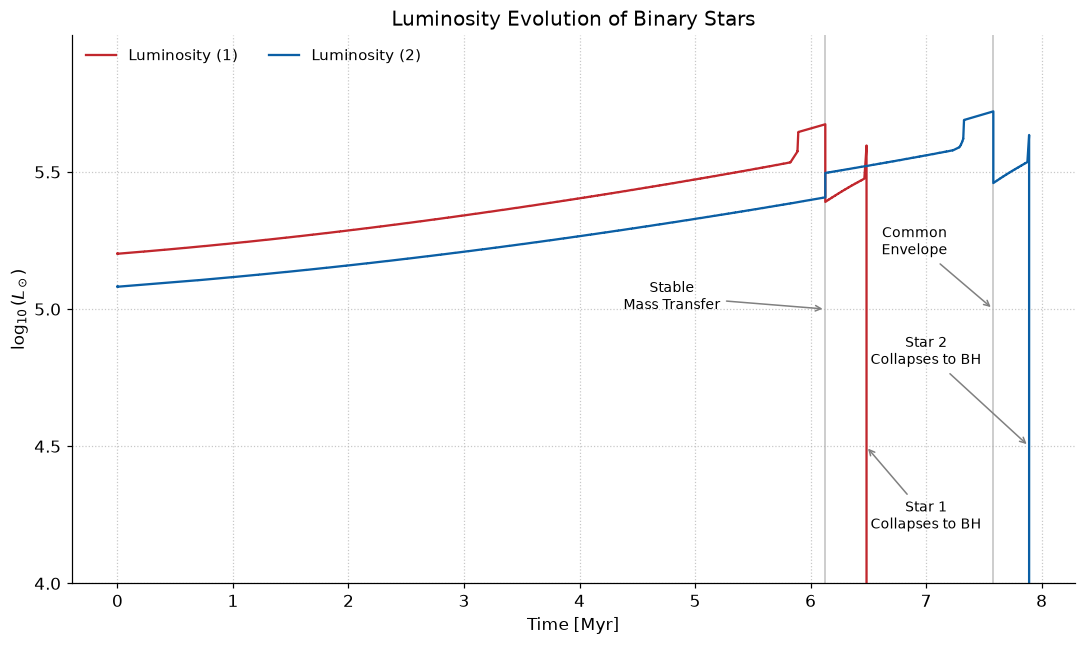

In [17]:
# Hard-coding the coordinates

fig, ax = plt.subplots(figsize=(10,6)) 

ax.plot(df["Time"], np.log10(df["Luminosity(1)"]), label="Luminosity (1)", color=C1, linestyle="-") 
ax.plot(df["Time"], np.log10(df["Luminosity(2)"]), label="Luminosity (2)", color=C2, linestyle="-") 

for _, ev in events[events.event.str.startswith("***")].iterrows(): 
    ax.axvline(ev["Time [Myr]"], color="grey", lw=1, ls="-", alpha=0.5, zorder=0)  

ax.annotate('Star 1\nCollapses to BH', xy=(6.48, 4.5), xytext=(7, 4.2), fontsize=9, ha="center", arrowprops=dict(arrowstyle='->', color='grey', lw=1)) 
ax.annotate("Stable\nMass Transfer", xy=(6.13, 5), xytext=(4.8, 5), fontsize=9, ha="center", arrowprops=dict(arrowstyle='->', color='grey', lw=1)) 
ax.annotate("Common\nEnvelope", xy=(7.58, 5), xytext=(6.9, 5.2), fontsize=9, ha="center", arrowprops=dict(arrowstyle='->', color='grey', lw=1)) 
ax.annotate('Star 2\nCollapses to BH', xy=(7.89, 4.5), xytext=(7, 4.8), fontsize=9, ha="center", arrowprops=dict(arrowstyle='->', color='grey', lw=1)) 

ax.set_ylim(4, 6) 
ax.set_yticks(np.arange(4, 6, 0.5))
ax.set_xlabel("Time [Myr]") 
ax.set_ylabel(r"$\log_{10}(L_\odot)$") 
ax.set_title("Luminosity Evolution of Binary Stars") 
ax.legend(loc='upper left', fontsize=10, ncol=3) 
plt.grid(True, alpha=0.7)
plt.tight_layout() 
plt.show()

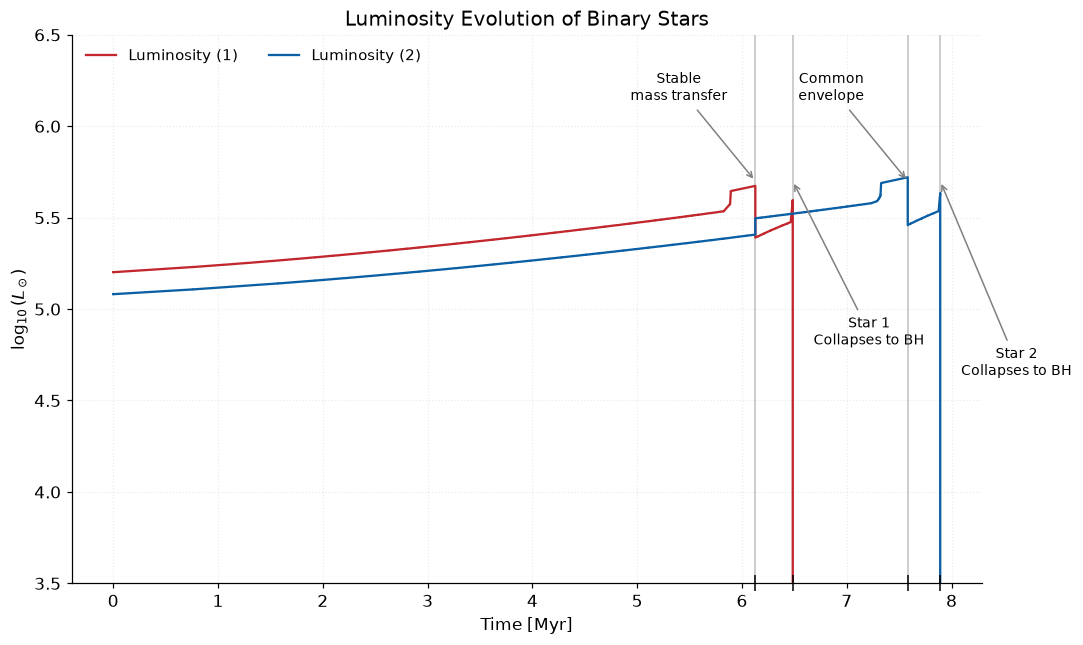

In [18]:
# Automating the process

fig, ax = plt.subplots(figsize=(10,6))

logL1 = np.log10(df["Luminosity(1)"])
logL2 = np.log10(df["Luminosity(2)"])

ax.plot(df["Time"], logL1, label="Luminosity (1)", color=C1)
ax.plot(df["Time"], logL2, label="Luminosity (2)", color=C2)

# Important Events

key_events = events[events.event.str.contains("stable mass transfer|common envelope|-> black Hole", 
                    case=False, regex=True)].sort_values("Time [Myr]")

# annotation_offsets = [(-40, 50), (40, -60), (-40, 20), (-65, -140)]

# Iterate through the key events and annotate them on the plot

for i, (_, ev) in enumerate(key_events.iterrows()):
    t = ev["Time [Myr]"]
    event = ev["event"]
    # Annotate the important timeline on X-axis
    ax.axvline(t, color='grey', lw=1, ls="-", alpha=0.5, zorder=0)
    ax.plot(t, 3.5, marker='|', markersize=10, color='black', clip_on=False, zorder=10)
    ax.annotate(f"{t:.2f}", xy=(t, 3), xytext=(0, -10), textcoords="offset points", ha="center", va="top", rotation=45, fontsize=8)
    # Determine the label for the annotation based on the event type
    if event.startswith("***"): 
        if "stable mass transfer" in event.lower(): 
            label = "Stable\nmass transfer" 
        elif "common envelope" in event.lower(): 
            label = "Common\nenvelope" 
        else: 
            label = event.strip("* ") 
    elif "-> black hole" in event.lower(): 
        star = event.split(":")[0].title() 
        label = f"{star}\nCollapses to BH" 
    else: label = event

    # Annotate the event with an arrow on the plot
    column = i % 2      # I alternate the annotation positions between two columns to avoid overlap
    row = i // 2        # I calculate the row number to stagger the annotations vertically

    dx = -50 if column == 0 else 50                   # Then alternate dx, dy according to the column and row
    dy = 50 if column == 0 else -100 - i * 10         # All the numbers are purely for visual purposes. You can change them to your preferences.

    # dx, dy = annotation_offsets[i % len(annotation_offsets)]    Can also use this to use with the pre-defined offsets.
    ax.annotate(label, xy=(t, 5.7), xytext=(dx, dy), textcoords="offset points", ha="center", va="bottom", fontsize=9, 
                arrowprops=dict(arrowstyle="->", color="grey", lw=1))
    # I used the y-coordinate of 5.7 for the annotation to place it above the plot, 
    # but you can adjust this value based on your data range and preferences.

ax.set_ylim(3.5, 6.5)
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"$\log_{10}(L_\odot)$")
ax.set_title("Luminosity Evolution of Binary Stars")
ax.legend(loc='upper left', fontsize=10, ncol=3)
plt.tight_layout()
plt.show()

### $T_{eff}(1)$ and $T_{eff}(2)$ vs $Time[Myr]$

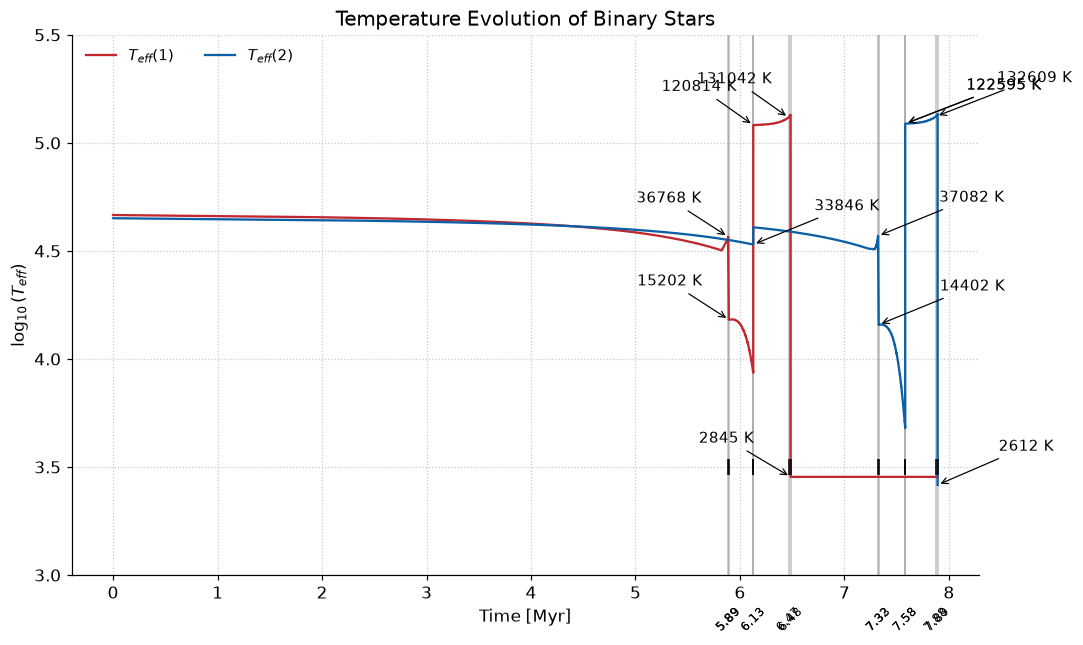

The star 1 reaches the highest temperature: 131042 K


In [19]:

fig, ax = plt.subplots(figsize=(10,6)) 

ax.plot(df["Time"], np.log10(df["Teff(1)"]), label="$T_{eff} (1)$", color=C1, linestyle="-") 
ax.plot(df["Time"], np.log10(df["Teff(2)"]), label="$T_{eff} (2)$", color=C2, linestyle="-") 

# Important Events

key_events = events.sort_values("Time [Myr]")

# Iterate through the key events and annotate them on the plot

for i, (_, ev) in enumerate(key_events.iterrows()):
    t = ev["Time [Myr]"]
    event = ev["event"]
    # Annotate the important timeline on X-axis
    ax.axvline(t, color='grey', lw=1, ls="-", alpha=0.5, zorder=0)
    ax.plot(t, 3.5, marker='|', markersize=10, color='black', clip_on=False, zorder=10)
    ax.annotate(f"{t:.2f}", xy=(t, 3), xytext=(0, -20), textcoords="offset points", ha="center", va="top", rotation=45, fontsize=8)
    if ev["star"] == 1:
        T = ev["T_{eff}(1)"]
        ax.annotate(f"{T:.0f} K", xy=(t, np.log10(T)), xytext=(-60,20), textcoords="offset points", ha="left", va="bottom", fontsize=10,
                        arrowprops=dict(arrowstyle='->', lw=0.8))
    elif ev["star"] == 2:
        T = ev["T_{eff}(2)"]
        ax.annotate(f"{T:.0f} K", xy=(t, np.log10(T)), xytext=(40,20), textcoords="offset points", ha="left", va="bottom", fontsize=10,
                        arrowprops=dict(arrowstyle='->', lw=0.8))
    else:
        continue

ax.set_yticks(np.arange(3, 6, 0.5))
ax.set_xlabel("Time [Myr]") 
ax.set_ylabel(r"$\log_{10}(T_{eff})$") 
ax.set_title("Temperature Evolution of Binary Stars") 
ax.legend(loc='upper left', fontsize=10, ncol=3) 
plt.grid(True, alpha=0.7)
plt.tight_layout() 
plt.show()


print(f"The star 1 reaches the highest temperature: 131042 K")

### Common Envelope $(CE)$ vs $Time[Myr]$

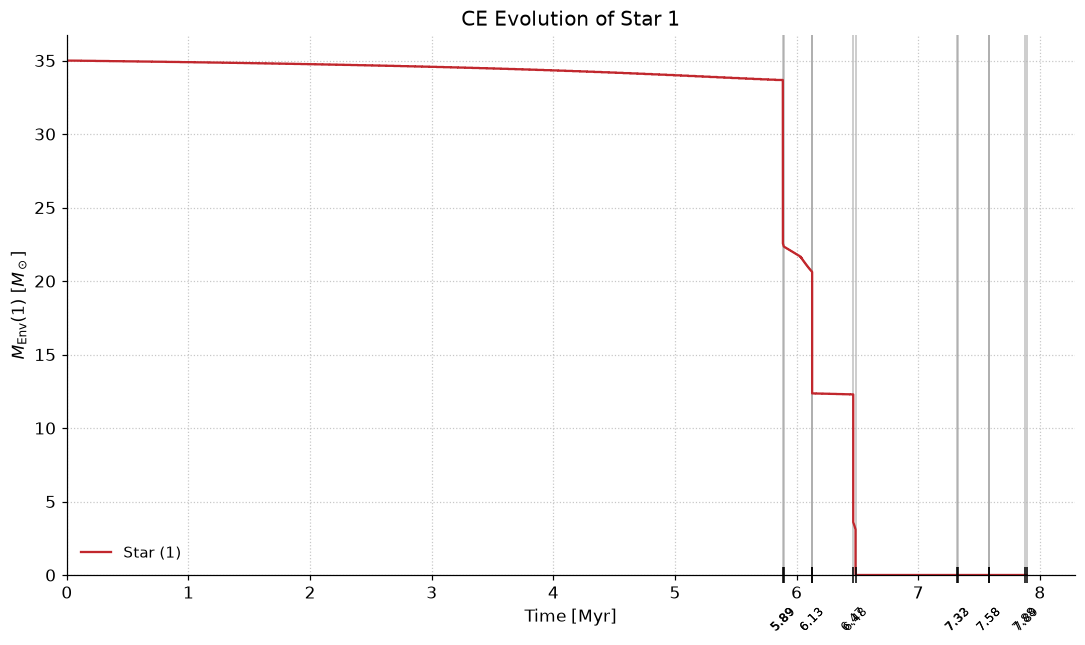

In [20]:
fig, ax = plt.subplots(figsize=(10,6)) 

ax.plot(df["Time"], df["Mass_Env(1)"], label="Star (1)", color=C1, linestyle="-") 

# Important Events
for _, ev in events.iterrows():
    t = ev["Time [Myr]"]
    event = ev["event"]
    # Annotate the important timeline on X-axis
    ax.axvline(t, color='grey', lw=1, ls="-", alpha=0.5, zorder=0)
    ax.plot(t, 0, marker='|', markersize=10, color='black', clip_on=False, zorder=10)
    ax.annotate(f"{t:.2f}", xy=(t, 0), xytext=(0, -20), textcoords="offset points", ha="center", va="top", rotation=45, fontsize=8)
    
# key_events = events.sort_values("Time [Myr]")
ax.set_xlim(left=0)                # Setting the axis to (0,0)
ax.set_ylim(bottom=0)
ax.set_xlabel("Time [Myr]") 
ax.set_ylabel(r"$M_{\rm Env}(1)\ [M_\odot]$") 
ax.set_title("CE Evolution of Star 1") 
ax.legend(loc=3, fontsize=10, ncol=3) 
plt.grid(True, alpha=0.7)
plt.tight_layout() 
plt.show()

### $Mass_{CO-core}$ vs $Mass_{He-core}$

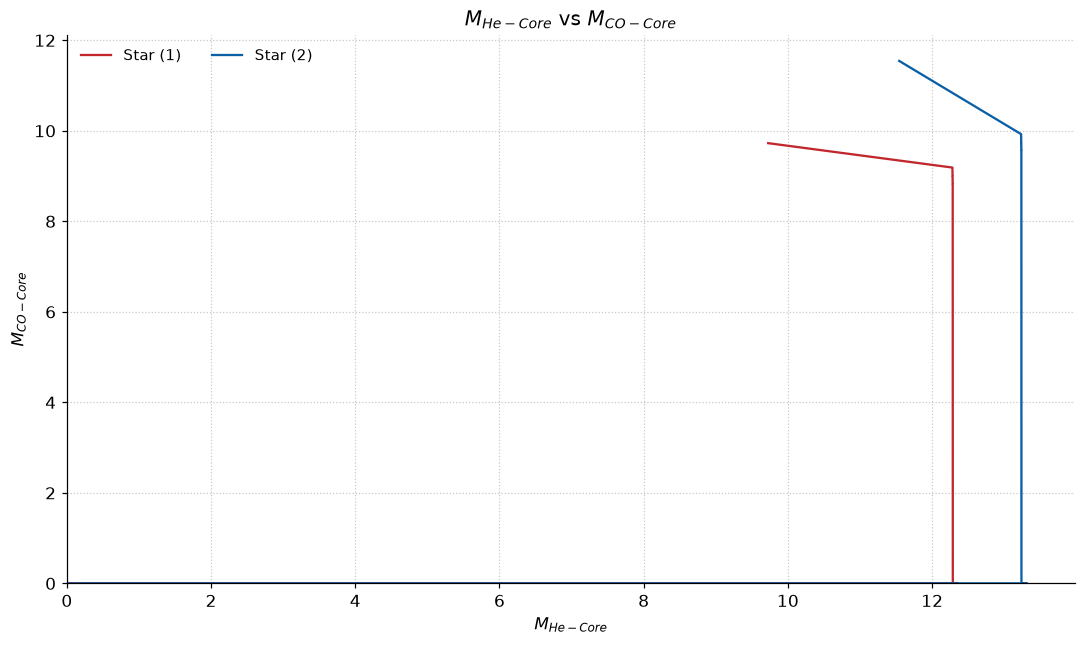

In [21]:
fig, ax = plt.subplots(figsize=(10,6)) 

ax.plot(df["Mass_He_Core(1)"], df["Mass_CO_Core(1)"], label="Star (1)", color=C1, linestyle="-") 
ax.plot(df["Mass_He_Core(2)"], df["Mass_CO_Core(2)"], label="Star (2)", color=C2, linestyle="-") 

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$M_{He-Core}$") 
ax.set_ylabel(r"$M_{CO-Core}$") 
ax.set_title(r"$M_{He-Core}$ vs $M_{CO-Core}$") 
ax.legend(loc=2, fontsize=10, ncol=3) 
plt.grid(True, alpha=0.7)
plt.tight_layout() 
plt.show()

## Exercise 3

In [22]:
# --- Exercise 3: merger time ----------------------------------------------------
# SI constants, so this cell has no extra dependencies.
G_SI = 6.67430e-11      # m^3 kg^-1 s^-2
C_SI = 2.99792458e8     # m s^-1
MSUN = 1.98892e30       # kg
RSUN = 6.957e8          # m
GYR = 3.15576e16        # s

def merger_time(m1_msun, m2_msun, a_rsun):
    '''Peters (1964) gravitational-wave merger timescale for a circular orbit.

    Returns the time to merge in Gyr.
    '''
    m1, m2, a = m1_msun * MSUN, m2_msun * MSUN, a_rsun * RSUN

    t = (5/256) * (a**4) * (C_SI**5) / (G_SI**3 * m1 * m2 * (m1+m2) * GYR)
    return t

t = merger_time(df["Mass(1)"].iloc[-1], df["Mass(2)"].iloc[-1], df["SemiMajorAxis"].iloc[-1])
print(f"merger time = {t:.3f} Gyr  (age of the Universe = 13.8 Gyr)")

merger time = 0.606 Gyr  (age of the Universe = 13.8 Gyr)
